# 4 — A study, and what it says

Level 3: N training runs. It has **no type** — a study is a `for` — and that is
on purpose. A graph earns its keep when there are dependencies to declare, and
between two trials there are none.

What lives in the library is what the `for` asks for, and it all has the same
shape: **numbers in, a decision out, never a tensor**. That is what lets it all
be Rust while the loop stays in Python, where torch is. No callback crosses.

In [1]:
import math
import tempfile

import torch

import somatize.torch  # noqa: F401
from somatize import Graph, Node, Opaque, Store
from somatize.study import (
    DONE,
    PRUNED,
    Pruner,
    Sampler,
    Space,
    coordinates,
    curves,
    finished,
    importance,
    influence,
    report,
    table,
    take,
    trials,
)
from somatize.torch import Trainer, parameters

torch.manual_seed(0)

## The space is declared, and it is read back from text

A record keeps a point **as text** beside its score, so rebuilding a whole
history costs one scan and no fetches. Text alone is ambiguous — is `batch=64`
a number or an option called `"64"`? — so the space is what parses it.

In [2]:
space = (
    Space()
    .real("lr", 1e-4, 1e-1, log=True)
    .int("width", 8, 64)
    .choice("opt", ["adam", "sgd"])
)
space

Space(lr=logreal(0.0001,0.1),width=int(8,64),opt=choice(adam|sgd))

## `ask` is a function of the trial **number**

Not of what was asked before. That is the property the whole distributed half
rests on: a machine that claims trial 7 works out where to look on its own,
without replaying the first six and without asking anybody.

`Halton` and `Sobol` cover the space **for every prefix** rather than in
expectation, which is what stops two machines proposing neighbours.

In [3]:
sampler = Sampler.sobol(seed=0)
for trial in range(4):
    print(trial, sampler.ask(space, trial, []))

0 lr=0.002771855228616633,width=44,opt=sgd
1 lr=0.08765375866675294,width=15,opt=adam
2 lr=0.015587287424960756,width=58,opt=sgd
3 lr=0.0004929133080657691,width=29,opt=adam


## The loop

`take` claims a trial, `report` writes down where it got to, `finished` reads
the history back. They are **functions over a `Store`**, like `gather`: what is
being touched is a folder, and a class around one would be the store with a
longer name.

Run this same script on eight machines over a shared folder and it is a
distributed study. There is no server, no port and no protocol: a trial is a
number, and `claim` settles who gets it — so the state **is** the queue.

In [4]:
truth = torch.randn(8, 1)


def batch(how_many=64):
    x = torch.randn(how_many, 8)
    return x, x @ truth + 0.1 * torch.randn(how_many, 1)


class Body(Node):
    def __init__(self, width):
        self.net = torch.nn.Sequential(torch.nn.Linear(8, width), torch.nn.ReLU())

    def forward(self, x, ctx):
        return Opaque(self.net(x))

    def parameters(self):
        return list(self.net.parameters())


class Head(Node):
    def __init__(self, width):
        self.out = torch.nn.Linear(width, 1)

    def forward(self, x, ctx):
        return Opaque(self.out(x))

    def parameters(self):
        return list(self.out.parameters())


def trained(point, epochs, pruner=None, so_far=()):
    """One trial: builds what the point says, trains it, reports as it goes."""
    g = Graph.somatize(Body(point["width"]).named("body") >> Head(point["width"]).named("head"))
    make = torch.optim.Adam if point["opt"] == "adam" else torch.optim.SGD
    t = Trainer(g, objective=torch.nn.functional.mse_loss,
                optimizer=make(parameters(g), lr=point["lr"]))
    said = []
    for epoch in range(epochs):
        said.append(sum(t.step(batch()) for _ in range(10)) / 10)
        # A pruner **stops nothing**: it answers, and the loop stops calling.
        if pruner is not None and (why := pruner.verdict(said, list(so_far))):
            return said, why
    return said, None

In [5]:
STUDY = "widths"
store = Store(tempfile.mkdtemp())
me = "this machine"
pruner = Pruner.median(goal="min", warmup=4, startup=6)

for trial in range(30):
    point = sampler.ask(space, trial, finished(store, space, study=STUDY))
    if not take(store, point, study=STUDY, trial=trial, me=me, goal="min"):
        continue  # somebody else has that one
    # `curves` is the one reader that pays: a curve grows, so it lives in the
    # blob and this is a scan plus a fetch per trial. Everything else is a scan.
    said, why = trained(point, epochs=8, pruner=pruner, so_far=curves(store, study=STUDY))
    report(store, point, said, study=STUDY, trial=trial, me=me,
           state=PRUNED if why else DONE, because=why, goal="min")

seen = trials(store, space, study=STUDY)
print(len(seen), "trials,", sum(one["state"] == PRUNED for one in seen), "pruned")

30 trials, 16 pruned


## The table of results

`trials` is one scan and no fetches — the configuration and the score are both
in the record, which is what makes a study readable from a machine that ran
none of it. `table` draws exactly that.

**A pruned score is not comparable with a finished one.** It is real, and it
was measured after fewer epochs, so ranking the two together says a trial that
was stopped early did badly when all that is known is that it was stopped. The
table shows both with their state; `influence` and `coordinates` below use only
the ones that ran to the end, and that is why `finished` leaves pruned trials
out too.

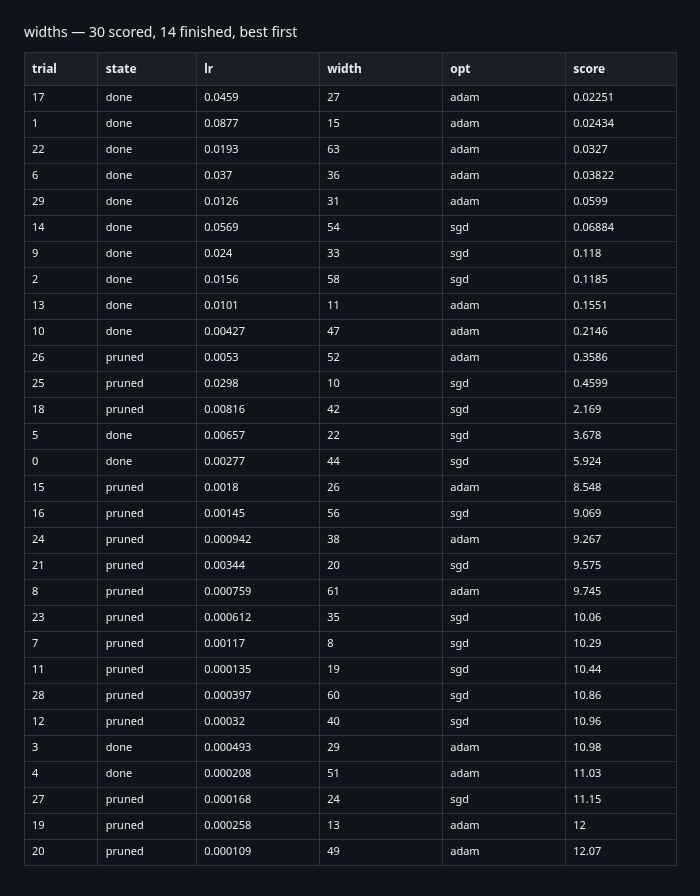

In [6]:
table(store, space, study=STUDY)

## Which knob mattered

**Spearman's ρ**, which is a rank correlation: how well the score follows each
knob, monotonically, without assuming a shape. The original soma documents
fANOVA as deferred and never implemented it — what it has is this, and this is
thirty lines of plain Python, so it lives in the library rather than becoming
a dependency.

`importance` gives the numbers and `influence` draws them. A bar near zero is a
knob you can stop searching; one near one is the knob the study is about.

In [7]:
importance(store, space, study=STUDY)

[('lr', 0.8989010989010989),
 ('opt', 0.2403700850309326),
 ('width', 0.08131868131868132)]

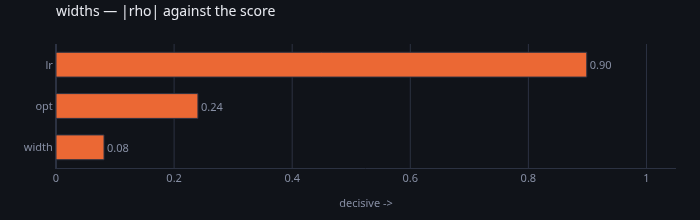

In [8]:
influence(store, space, study=STUDY)

## Parallel coordinates

Every finished trial is a **curve** across the knobs, coloured by its score. It
is the one picture that shows a *region* of the space rather than one knob at a
time — where the good curves bunch together is where to look next.

Drawn by hand out of splines rather than with plotly's `Parcoords`, which only
draws straight segments. What that costs is `Parcoords`' brushing; what it buys
is that a trial reads as one continuous thing instead of a zigzag, which is
what makes a bundle visible as a bundle.

A curve here claims nothing: a point exists only where it crosses an axis, and
it crosses at the value it has. The axis for a knob whose values span more than
fifty-fold is drawn in log, which is how it was almost certainly searched.

`goal` decides which end of the colour scale is good, and it is a parameter
rather than a guess: getting it backwards is the quietest lie a figure can
tell — everything is drawn, nothing raises, and the region you read as
promising is the one to stay away from.

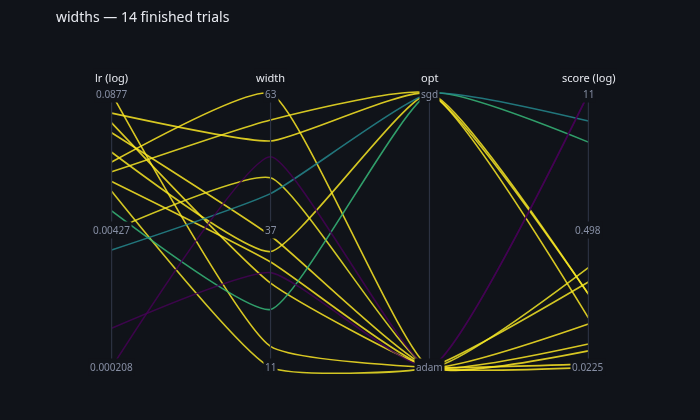

In [9]:
coordinates(store, space, study=STUDY)

## What is not here

`curves(store, study=…)` is the reader a pruner uses, and it is the one that
**pays**: a curve grows, so it lives in the blob, and reading them is a scan
plus one fetch per trial. Everything above cost one scan.